In [1]:
# =========================
# 0. Install XAI Libraries
# =========================
!pip install lime shap -q

print("✅ XAI libraries installed!")

✅ XAI libraries installed!


In [2]:
# =========================
# 1. Imports
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample

# TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                      Bidirectional, BatchNormalization,
                                      GlobalMaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam

# XAI
import shap
from lime.lime_text import LimeTextExplainer

print("✅ All imports loaded!")

✅ All imports loaded!


In [3]:
# =========================
# 2. Load & Clean Data
# =========================
data_path = "/kaggle/input/datasets/saimulhaque/disaster/different_types_of_disaster_processed.xlsx"
data = pd.read_excel(data_path)

def clean_text(text):
    text = re.sub(r"http\S+|www\S+", "", str(text))
    text = re.sub(r"@\w+|#", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)
    return text.lower().strip()

data['clean_tweet'] = data['tweet_text'].apply(clean_text)
data = data.dropna(subset=['disaster_type'])

# Encode labels
label_enc = LabelEncoder()
data['label'] = label_enc.fit_transform(data['stage_value'])
class_names = label_enc.classes_

print(f"Classes: {class_names}")
print(f"Total samples: {len(data)}")

Classes: ['1st Stage' '2nd Stage' '3rd Stage']
Total samples: 42953


In [4]:
# =========================
# 3. THREE-WAY SPLIT (Train 70%, Val 15%, Test 15%)
# =========================
X = data['clean_tweet']
y = data['label']

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Second split: 15% validation, 15% test (from the 30%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"✅ Train: {len(X_train)} samples")
print(f"✅ Validation: {len(X_val)} samples")
print(f"✅ Test: {len(X_test)} samples")

✅ Train: 30067 samples
✅ Validation: 6443 samples
✅ Test: 6443 samples


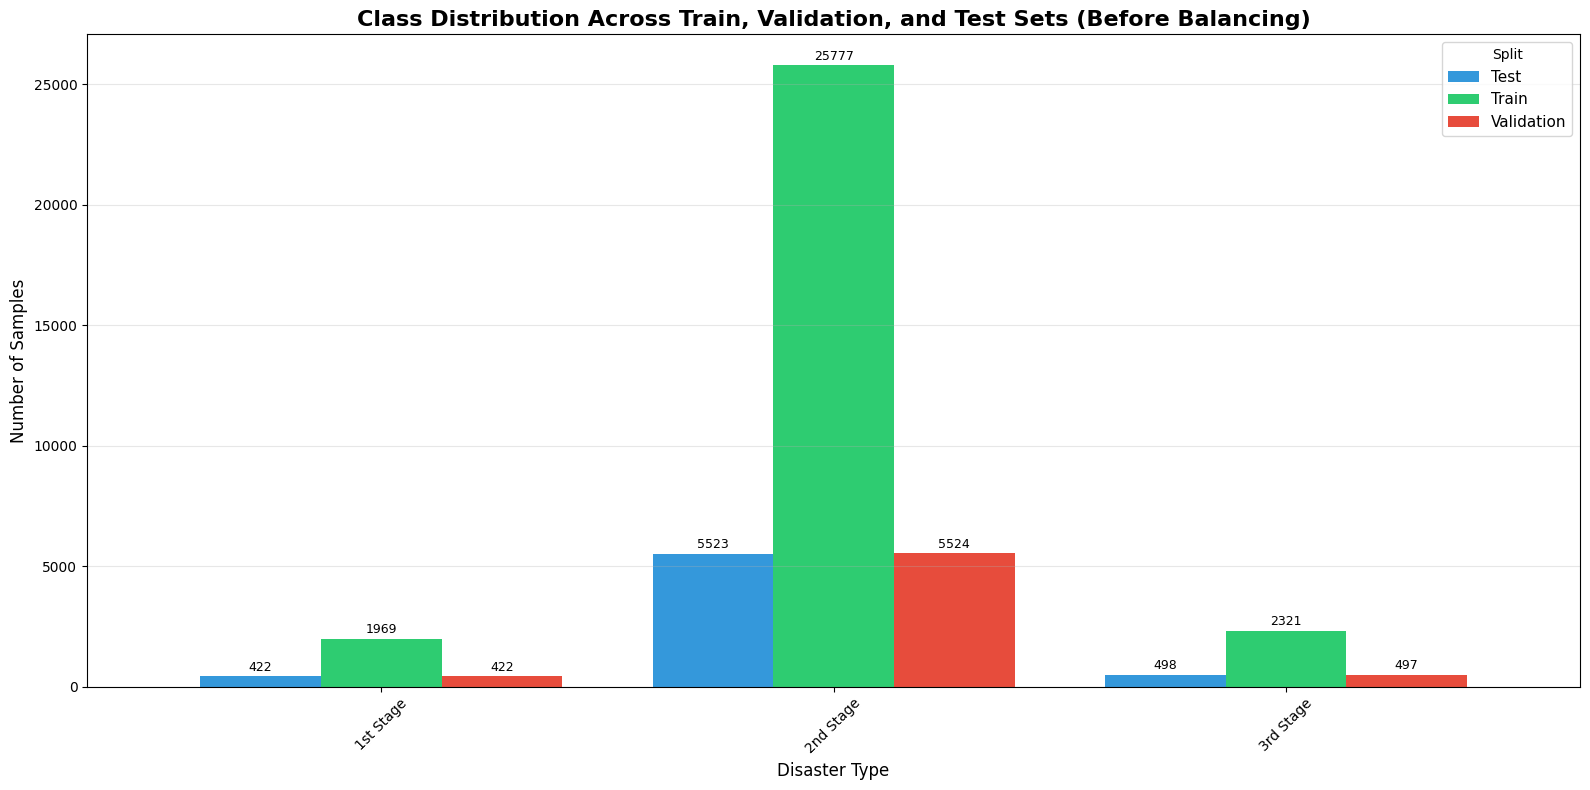

✅ Saved: class_distribution_before_balancing.png


In [5]:
# =========================
# 4. Class Distribution Visualization (Before Balancing)
# =========================
# Create DataFrame for visualization
split_data = pd.DataFrame({
    'class': np.concatenate([y_train, y_val, y_test]),
    'split': ['Train']*len(y_train) + ['Validation']*len(y_val) + ['Test']*len(y_test)
})

# Count per class and split
split_counts = split_data.groupby(['class', 'split']).size().unstack(fill_value=0)
split_counts.index = [class_names[i] for i in split_counts.index]

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
split_counts.plot(kind='bar', ax=ax, color=['#3498db', '#2ecc71', '#e74c3c'], width=0.8)
ax.set_title('Class Distribution Across Train, Validation, and Test Sets (Before Balancing)', fontsize=16, fontweight='bold')
ax.set_xlabel('Disaster Type', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.legend(title='Split', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('class_distribution_before_balancing.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution_before_balancing.png")

In [6]:
# =========================
# 5. Balance ONLY Training Data
# =========================
train_df = pd.DataFrame({'clean_tweet': X_train, 'label': y_train})
counts = Counter(train_df['label'])
max_count = max(counts.values())
min_count = min(counts.values())

print(f"Before balancing - Train: {dict(counts)}")

# Oversample minority classes
oversampled_list = []
for label in counts:
    df_label = train_df[train_df['label'] == label]
    if len(df_label) < max_count:
        df_label = resample(df_label, replace=True, n_samples=max_count, random_state=42)
    oversampled_list.append(df_label)
train_df_over = pd.concat(oversampled_list)

# Undersample all classes to midpoint
target_count = int((max_count + min_count) / 2)
final_balanced_list = []
for label in Counter(train_df_over['label']):
    df_label = train_df_over[train_df_over['label'] == label]
    if len(df_label) > target_count:
        df_label = resample(df_label, replace=False, n_samples=target_count, random_state=42)
    final_balanced_list.append(df_label)
train_df_balanced = pd.concat(final_balanced_list)

X_train_bal = train_df_balanced['clean_tweet']
y_train_bal = train_df_balanced['label']

print(f"After balancing - Train: {Counter(y_train_bal)}")

Before balancing - Train: {1: 25777, 0: 1969, 2: 2321}
After balancing - Train: Counter({1: 13873, 0: 13873, 2: 13873})


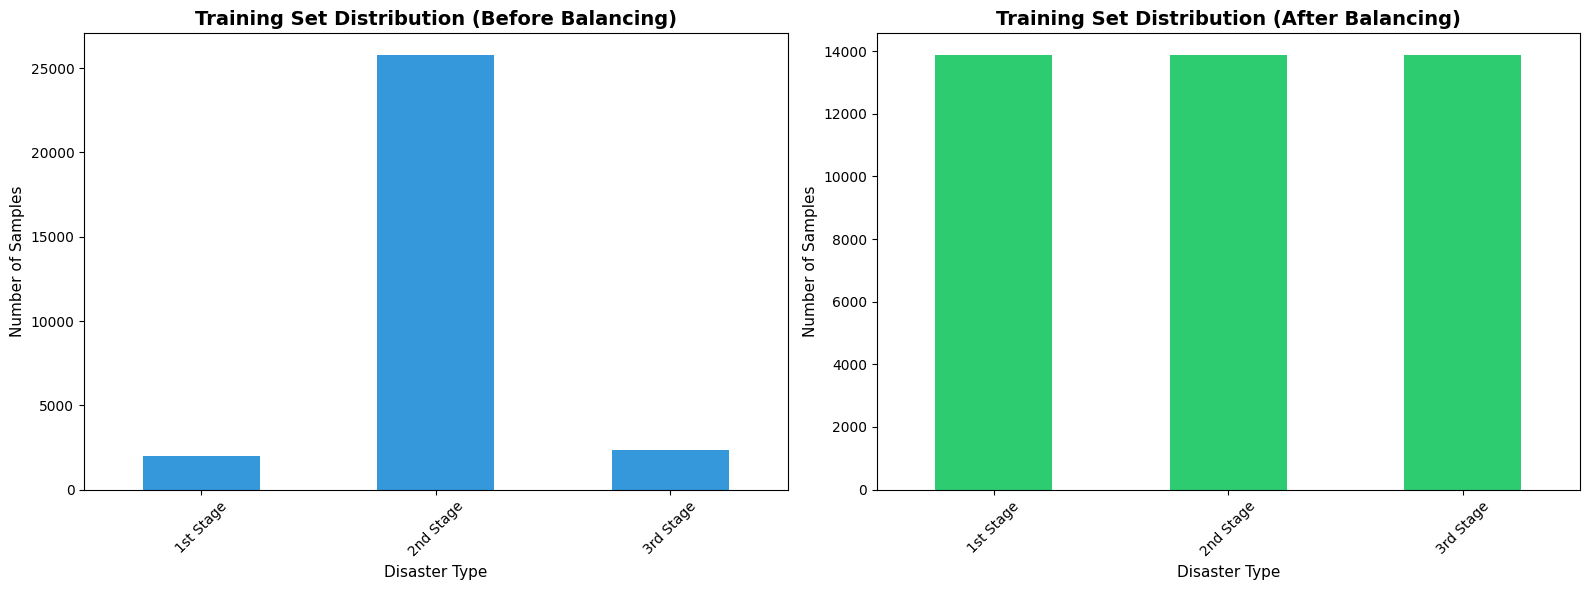

✅ Saved: class_distribution_balancing_comparison.png


In [7]:
# =========================
# 6. Class Distribution After Balancing (Visualization)
# =========================
# Show before vs after balancing
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before balancing
before_counts = Counter(y_train)
before_df = pd.DataFrame({
    'Count': [before_counts[i] for i in range(len(class_names))]
}, index=class_names)

before_df.plot(kind='bar', ax=axes[0], color='#3498db', legend=False)
axes[0].set_title('Training Set Distribution (Before Balancing)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Disaster Type', fontsize=11)
axes[0].set_ylabel('Number of Samples', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

# After balancing
after_counts = Counter(y_train_bal)
after_df = pd.DataFrame({
    'Count': [after_counts[i] for i in range(len(class_names))]
}, index=class_names)

after_df.plot(kind='bar', ax=axes[1], color='#2ecc71', legend=False)
axes[1].set_title('Training Set Distribution (After Balancing)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Disaster Type', fontsize=11)
axes[1].set_ylabel('Number of Samples', fontsize=11)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('class_distribution_balancing_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: class_distribution_balancing_comparison.png")

In [8]:
# =========================
# 7. Tokenization
# =========================
max_words = 15000
max_len = 120

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_bal)  # Fit ONLY on balanced training data

X_train_seq = tokenizer.texts_to_sequences(X_train_bal)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

print(f"Train: {X_train_pad.shape}, Val: {X_val_pad.shape}, Test: {X_test_pad.shape}")

Train: (41619, 120), Val: (6443, 120), Test: (6443, 120)


In [9]:
# =========================
# 8. Enhanced Model Architecture
# =========================
def build_model():
    model = Sequential()

    model.add(Embedding(max_words, 128, input_length=max_len))
    model.add(Bidirectional(LSTM(128, return_sequences=True,
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(Bidirectional(LSTM(64, return_sequences=True,
                                   dropout=0.3, recurrent_dropout=0.3,
                                   kernel_regularizer=l2(0.001))))
    model.add(BatchNormalization())
    model.add(Dropout(0.4))

    model.add(GlobalMaxPooling1D())
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))

    model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.001)))
    model.add(BatchNormalization())
    model.add(Dropout(0.3))

    model.add(Dense(len(class_names), activation='softmax'))

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

I0000 00:00:1787288267.104339      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787288267.107054      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
# =========================
# 9. Train with VALIDATION Set
# =========================
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.5, verbose=1)
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    X_train_pad, y_train_bal,
    validation_data=(X_val_pad, y_val),  # ← Using VALIDATION set!
    epochs=30,
    batch_size=64,
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

Epoch 1/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3883 - loss: 2.2548
Epoch 1: val_accuracy improved from None to 0.07605, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 749s 1s/step - accuracy: 0.5455 - loss: 1.7781 - val_accuracy: 0.0761 - val_loss: 2.7727 - learning_rate: 0.0010
Epoch 2/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9445 - loss: 0.7772
Epoch 2: val_accuracy improved from 0.07605 to 0.89632, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 729s 1s/step - accuracy: 0.9561 - loss: 0.6784 - val_accuracy: 0.8963 - val_loss: 0.6986 - learning_rate: 0.0010
Epoch 3/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9793 - loss: 0.4324
Epoch 3: val_accuracy improved from 0.89632 to 0.93078, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 737s 1s/step - accuracy: 0.9803 - loss: 0.3856 - val_accuracy: 0.9308 - val_loss: 0.4804 - learning_rate: 0.0010
Epoch 4/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9869 - loss: 0.2591
Epoch 4: val_accuracy improved from 0.93078 to 0.94568, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 736s 1s/step - accuracy: 0.9865 - loss: 0.2336 - val_accuracy: 0.9457 - val_loss: 0.3781 - learning_rate: 0.0010
Epoch 5/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9856 - loss: 0.1697
Epoch 5: val_accuracy improved from 0.94568 to 0.94583, saving model to best_model.h5


...


Epoch 7: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 735s 1s/step - accuracy: 0.9917 - loss: 0.0796 - val_accuracy: 0.9537 - val_loss: 0.2889 - learning_rate: 0.0010
Epoch 8/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9910 - loss: 0.0750
Epoch 8: val_accuracy did not improve from 0.95375
651/651 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.9909 - loss: 0.0749 - val_accuracy: 0.9260 - val_loss: 0.3912 - learning_rate: 0.0010
Epoch 9/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9917 - loss: 0.0725
Epoch 9: val_accuracy did not improve from 0.95375
651/651 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.9915 - loss: 0.0728 - val_accuracy: 0.9517 - val_loss: 0.3367 - learning_rate: 0.0010
Epoch 10/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9930 - loss: 0.0681
Epoch 10: val_accuracy did not improve from 0.95375
651/651 ━━━━━━━━━━━━━━━━━━━━ 735s 1s/step - accuracy: 0.9930 - loss: 0.0686 - val_accuracy: 0.9531 - val_loss: 0.26


Epoch 11: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.9923 - loss: 0.0696 - val_accuracy: 0.9618 - val_loss: 0.2408 - learning_rate: 0.0010
Epoch 12/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9933 - loss: 0.0695
Epoch 12: val_accuracy did not improve from 0.96182
651/651 ━━━━━━━━━━━━━━━━━━━━ 730s 1s/step - accuracy: 0.9926 - loss: 0.0698 - val_accuracy: 0.9534 - val_loss: 0.3060 - learning_rate: 0.0010
Epoch 13/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9940 - loss: 0.0593
Epoch 13: val_accuracy improved from 0.96182 to 0.96430, saving model to best_model.h5



Epoch 13: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 731s 1s/step - accuracy: 0.9937 - loss: 0.0608 - val_accuracy: 0.9643 - val_loss: 0.2254 - learning_rate: 0.0010
Epoch 14/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9943 - loss: 0.0649
Epoch 14: val_accuracy did not improve from 0.96430
651/651 ━━━━━━━━━━━━━━━━━━━━ 730s 1s/step - accuracy: 0.9941 - loss: 0.0688 - val_accuracy: 0.9367 - val_loss: 0.4263 - learning_rate: 0.0010
Epoch 15/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9948 - loss: 0.0591
Epoch 15: val_accuracy did not improve from 0.96430
651/651 ━━━━━━━━━━━━━━━━━━━━ 731s 1s/step - accuracy: 0.9943 - loss: 0.0603 - val_accuracy: 0.9604 - val_loss: 0.2978 - learning_rate: 0.0010
Epoch 16/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9944 - loss: 0.0596
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 16: val_accuracy did not improve from 0.96430
651/651 ━━━━━━━━━━━━━━━━━━━━ 730


Epoch 18: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 733s 1s/step - accuracy: 0.9979 - loss: 0.0305 - val_accuracy: 0.9682 - val_loss: 0.2052 - learning_rate: 5.0000e-04
Epoch 19/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9971 - loss: 0.0309
Epoch 19: val_accuracy improved from 0.96818 to 0.97175, saving model to best_model.h5



Epoch 19: finished saving model to best_model.h5
651/651 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.9971 - loss: 0.0301 - val_accuracy: 0.9718 - val_loss: 0.2031 - learning_rate: 5.0000e-04
Epoch 20/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9977 - loss: 0.0278
Epoch 20: val_accuracy did not improve from 0.97175
651/651 ━━━━━━━━━━━━━━━━━━━━ 732s 1s/step - accuracy: 0.9971 - loss: 0.0307 - val_accuracy: 0.9648 - val_loss: 0.2628 - learning_rate: 5.0000e-04
Epoch 21/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9971 - loss: 0.0321
Epoch 21: val_accuracy did not improve from 0.97175
651/651 ━━━━━━━━━━━━━━━━━━━━ 737s 1s/step - accuracy: 0.9972 - loss: 0.0325 - val_accuracy: 0.9673 - val_loss: 0.2225 - learning_rate: 5.0000e-04
Epoch 22/30
651/651 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9976 - loss: 0.0290
Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 22: val_accuracy did not improve from 0.97175
651/651 ━━━━━━━━━━━━

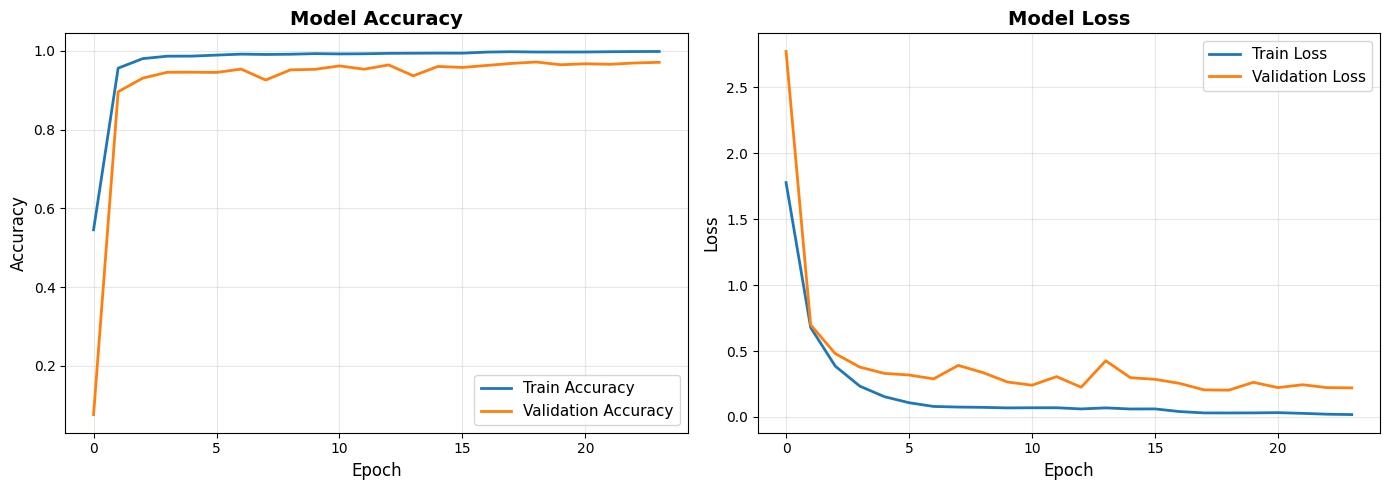

✅ Saved: training_history.png


In [11]:
# =========================
# 10. Training History Plots
# =========================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: training_history.png")

In [12]:
# =========================
# 11. FINAL EVALUATION on TEST Set (UNSEEN Data)
# =========================
from tensorflow.keras.models import load_model

# Load best model
best_model = load_model('best_model.h5')

# Final evaluation on test set
y_pred = best_model.predict(X_test_pad)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\n" + "="*70)
print("📊 FINAL CLASSIFICATION REPORT (on UNSEEN test data)")
print("="*70)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# Compare validation vs test accuracy
val_acc = max(history.history['val_accuracy'])
test_acc = np.mean(y_pred_classes == y_test)

print(f"\n📊 Accuracy Comparison:")
print(f"   Validation Accuracy (during training): {val_acc:.4f}")
print(f"   Test Accuracy (final evaluation):      {test_acc:.4f}")
print(f"   Gap: {val_acc - test_acc:.4f}")

if val_acc - test_acc > 0.02:
    print("   ⚠️ Overfitting detected! Consider more regularization.")
else:
    print("   ✅ Good generalization!")

202/202 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step

📊 FINAL CLASSIFICATION REPORT (on UNSEEN test data)
              precision    recall  f1-score   support

   1st Stage       0.93      0.79      0.86       422
   2nd Stage       0.97      0.99      0.98      5523
   3rd Stage       0.95      0.83      0.89       498

    accuracy                           0.97      6443
   macro avg       0.95      0.87      0.91      6443
weighted avg       0.97      0.97      0.97      6443


📊 Accuracy Comparison:
   Validation Accuracy (during training): 0.9718
   Test Accuracy (final evaluation):      0.9662
   Gap: 0.0056
   ✅ Good generalization!


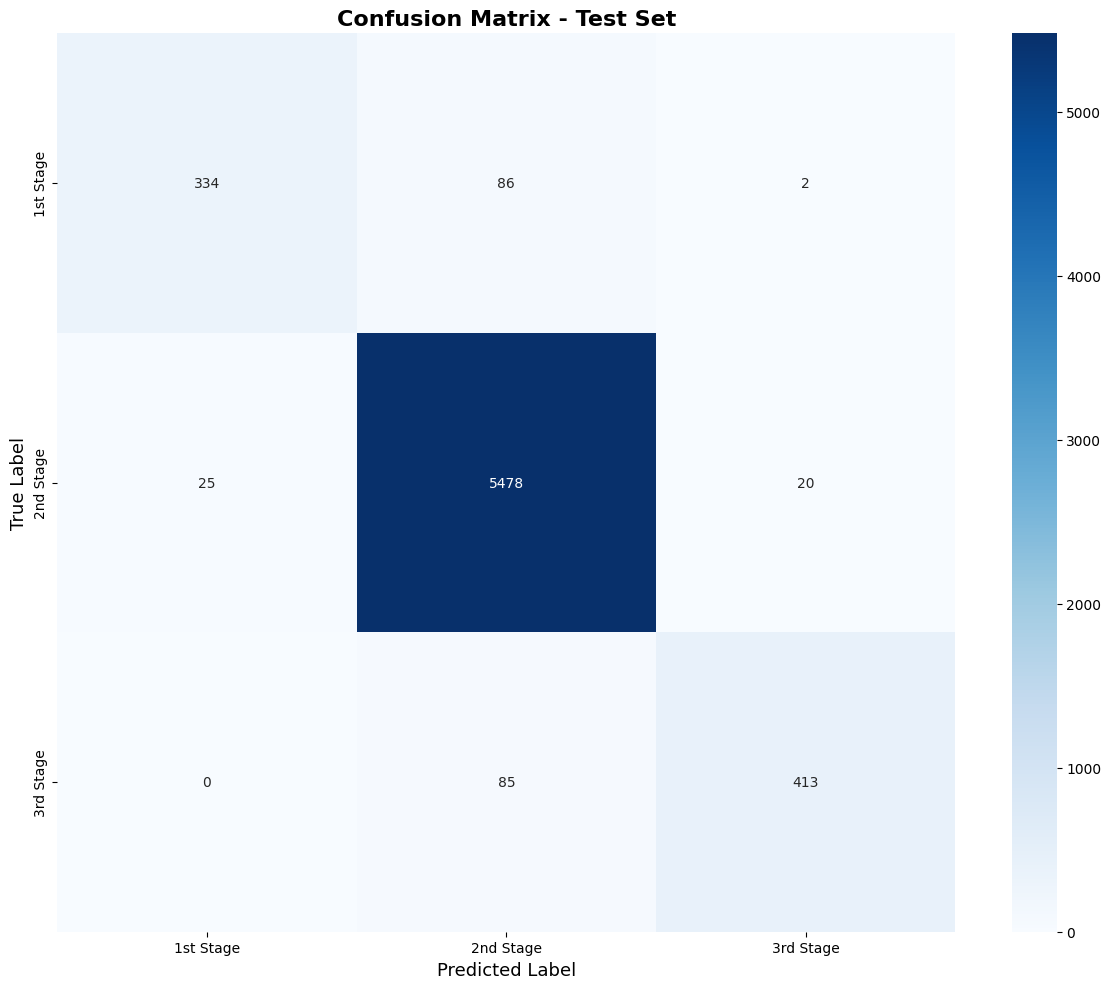

✅ Saved: confusion_matrix.png


In [13]:
# =========================
# 12. Confusion Matrix (High Resolution)
# =========================
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            annot_kws={'size': 10})
plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('True Label', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: confusion_matrix.png")

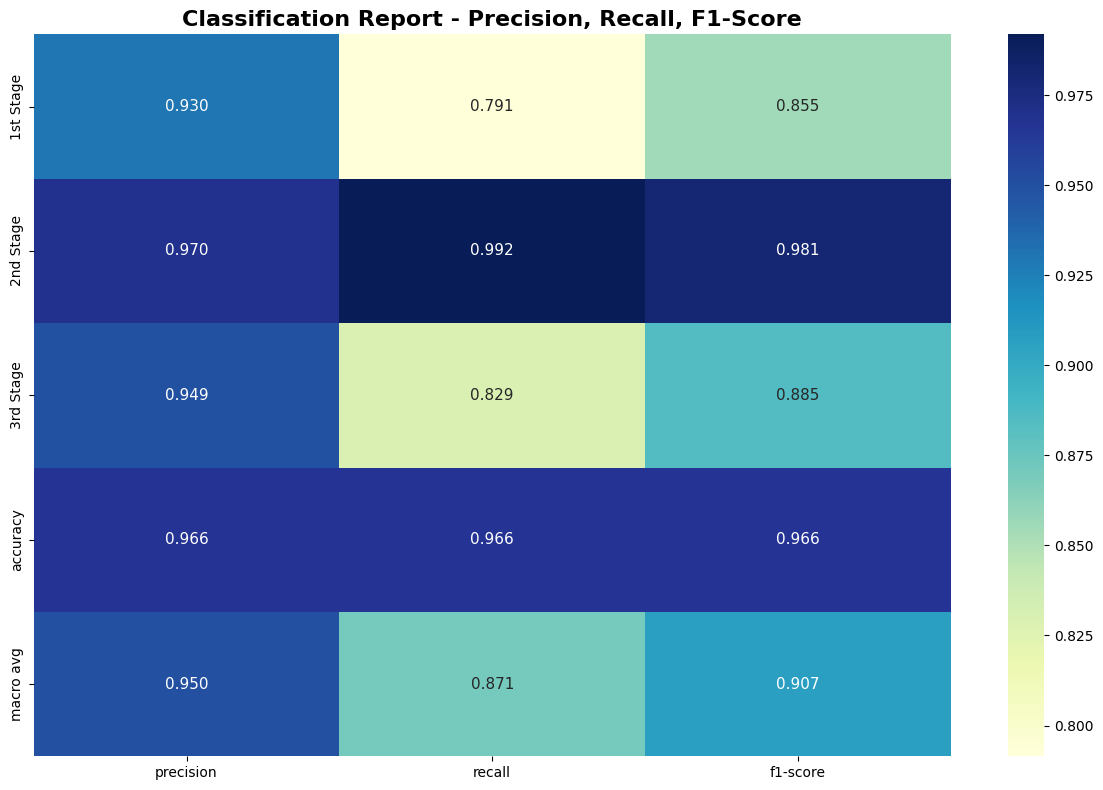

✅ Saved: classification_report_heatmap.png


In [14]:
# =========================
# 13. Classification Report Heatmap (High Resolution)
# =========================
report_dict = classification_report(
    y_test, y_pred_classes,
    target_names=class_names,
    output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose()

# Select only precision, recall, f1-score
report_metrics = report_df.iloc[:-1, :3]

plt.figure(figsize=(12, 8))
sns.heatmap(report_metrics, annot=True, fmt='.3f', cmap='YlGnBu',
            annot_kws={'size': 11})
plt.title('Classification Report - Precision, Recall, F1-Score', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('classification_report_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: classification_report_heatmap.png")

In [15]:
# =========================
# 14. Prediction Helper Functions
# =========================
def predict_proba(texts):
    if isinstance(texts, str):
        texts = [texts]
    seq = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    return best_model.predict(padded, verbose=0)

def predict(texts):
    return np.argmax(predict_proba(texts), axis=1)

print("✅ Prediction functions ready!")

✅ Prediction functions ready!


In [16]:
# =========================
# 15. XAI: LIME Explanations
# =========================
print("\n" + "="*70)
print("🔍 LIME EXPLANATIONS")
print("="*70)

lime_explainer = LimeTextExplainer(class_names=class_names)

# Explain sample predictions
for idx in range(5):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]

    print(f"\n🔹 Example {idx+1}: True={true_label}, Pred={pred_label}")
    print(f"   Text: {text[:150]}...")

    try:
        exp = lime_explainer.explain_instance(
            text,
            predict_proba,
            num_features=10,
            num_samples=500,
            top_labels=3
        )

        print("   📝 Top words:")
        for word, weight in exp.as_list(label=y_pred_classes[idx])[:8]:
            sign = "✅" if weight > 0 else "❌"
            print(f"      {sign} '{word}': {weight:.4f}")
    except Exception as e:
        print(f"   ⚠️ Error: {e}")

    print("-" * 50)


🔍 LIME EXPLANATIONS

🔹 Example 1: True=2nd Stage, Pred=2nd Stage
   Text: rt  no end in sight for australia flood victims brisbane at risk of running out of drinking water  connect...
   📝 Top words:
      ✅ 'connect': 0.0003
      ✅ 'running': 0.0003
      ❌ 'risk': -0.0002
      ✅ 'drinking': 0.0002
      ❌ 'at': -0.0002
      ✅ 'out': 0.0002
      ❌ 'rt': -0.0001
      ✅ 'australia': 0.0001
--------------------------------------------------

🔹 Example 2: True=2nd Stage, Pred=2nd Stage
   Text: rt  this is the new sexy in calgary love it abflood...
   📝 Top words:
      ✅ 'it': 0.0001
      ✅ 'the': 0.0000
      ❌ 'rt': -0.0000
      ✅ 'is': 0.0000
      ❌ 'love': -0.0000
      ❌ 'sexy': -0.0000
      ❌ 'in': -0.0000
      ✅ 'calgary': 0.0000
--------------------------------------------------

🔹 Example 3: True=2nd Stage, Pred=2nd Stage
   Text: rt  mother nature did i bone u not call first the hurricane cancelled my plans for nyc and now theres a threat...
   📝 Top words:
      ✅ '


📊 Generating LIME Multi-Example Grid


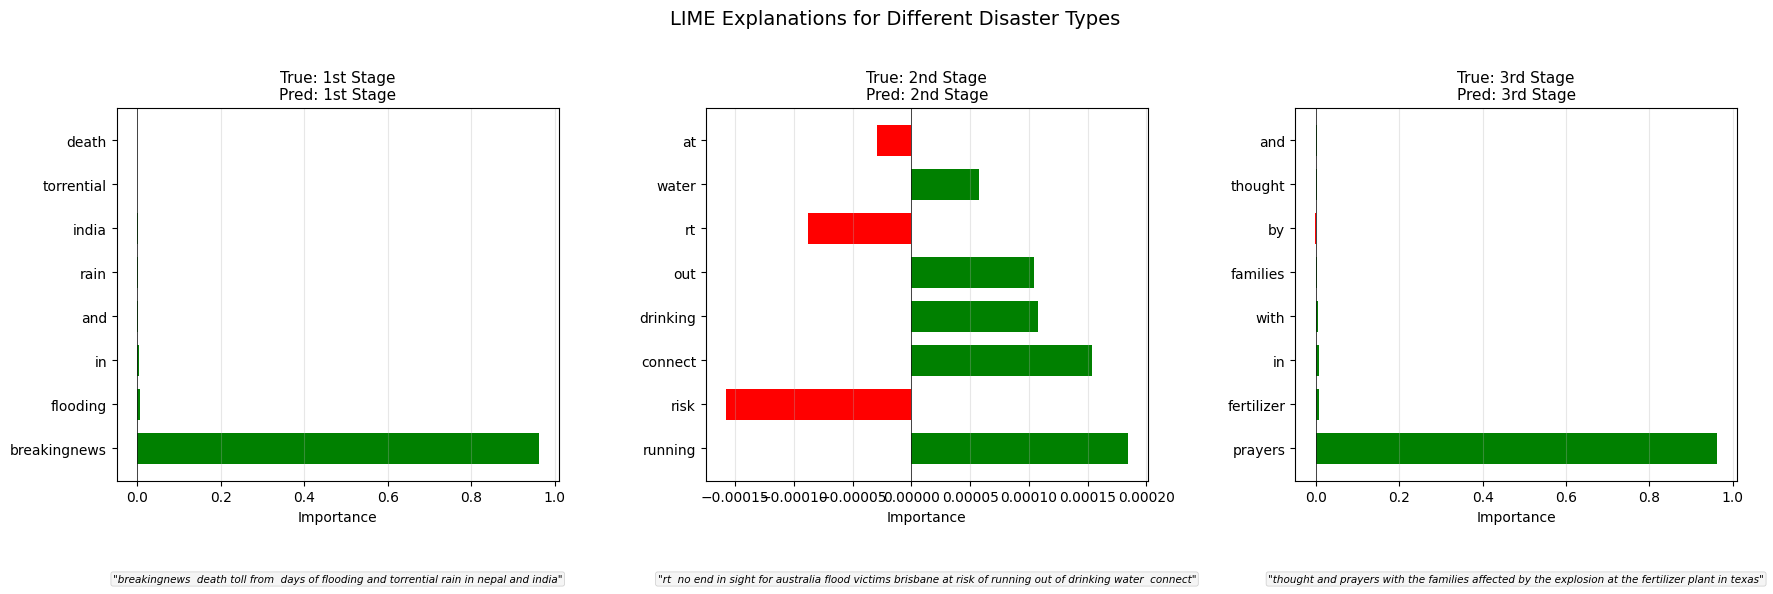

✅ Saved: lime_multi_examples.png


In [17]:
# =========================
# 16. XAI: LIME Multi-Example Grid
# =========================
print("\n📊 Generating LIME Multi-Example Grid")

# Select examples from different classes
example_indices = []
for class_idx in range(len(class_names)):
    indices = np.where(y_test == class_idx)[0]
    if len(indices) > 0:
        example_indices.append(indices[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for i, idx in enumerate(example_indices[:3]):
    text = X_test.iloc[idx]
    true_label = class_names[y_test.iloc[idx]]
    pred_label = class_names[y_pred_classes[idx]]

    exp = lime_explainer.explain_instance(
        text,
        predict_proba,
        num_features=8,
        num_samples=300,
        top_labels=3
    )

    exp_list = exp.as_list(label=y_pred_classes[idx])
    words = [item[0] for item in exp_list[:8]]
    weights = [item[1] for item in exp_list[:8]]

    colors = ['green' if w > 0 else 'red' for w in weights]

    axes[i].barh(words, weights, color=colors, height=0.7)
    axes[i].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    axes[i].set_xlabel('Importance', fontsize=10)
    axes[i].set_title(f'True: {true_label}\nPred: {pred_label}', fontsize=11)
    axes[i].grid(True, alpha=0.3, axis='x')

    # Add tweet text
    display_text = text[:120] + "..." if len(text) > 120 else text
    axes[i].text(0.5, -0.25, f'"{display_text}"',
                transform=axes[i].transAxes,
                fontsize=7.5, ha='center', va='top', wrap=True,
                style='italic',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#f5f5f5',
                         edgecolor='#cccccc', linewidth=0.5))

plt.suptitle('LIME Explanations for Different Disaster Types', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('lime_multi_examples.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: lime_multi_examples.png")

In [18]:
# =========================
# 17. Summary
# =========================
print("\n" + "="*70)
print("📋 MODEL PERFORMANCE SUMMARY")
print("="*70)

# Calculate per-class F1 scores
f1_scores = f1_score(y_test, y_pred_classes, average=None)

for i, class_name in enumerate(class_names):
    print(f"   {class_name}: F1 = {f1_scores[i]:.4f}")

print(f"\n   Macro F1: {np.mean(f1_scores):.4f}")
print(f"   Weighted F1: {f1_score(y_test, y_pred_classes, average='weighted'):.4f}")

print("\n📁 Images saved:")
print("   - class_distribution_before_balancing.png")
print("   - class_distribution_balancing_comparison.png")
print("   - training_history.png")
print("   - confusion_matrix.png")
print("   - classification_report_heatmap.png")
print("   - lime_multi_examples.png")
print("="*70)


📋 MODEL PERFORMANCE SUMMARY
   1st Stage: F1 = 0.8553
   2nd Stage: F1 = 0.9807
   3rd Stage: F1 = 0.8853

   Macro F1: 0.9071
   Weighted F1: 0.9651

📁 Images saved:
   - class_distribution_before_balancing.png
   - class_distribution_balancing_comparison.png
   - training_history.png
   - confusion_matrix.png
   - classification_report_heatmap.png
   - lime_multi_examples.png
